# Color Detection - 01: Dominant Colours with K-Means

Cluster an image's pixels in RGB space with K-Means; each cluster centre is a dominant colour and its cluster size is that colour's share of the image. We first validate on a synthetic image with known colours, then run it on natural photos.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils

## 1. Ground-truth check on a 4-colour block image

`blocks.png` was built from four exact colours: red (220,30,30), blue (30,140,220), green (40,180,60), yellow (240,210,30). A correct extractor should recover these four centres.

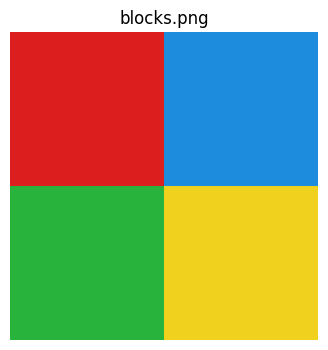

RGB (30, 140, 220)  share 0.25  -> teal
RGB (240, 210, 30)  share 0.25  -> yellow
RGB (220, 30, 30)  share 0.25  -> red
RGB (40, 180, 60)  share 0.25  -> green


In [2]:
blocks = utils.load_image('data/blocks.png')
plt.figure(figsize=(4,4)); plt.imshow(blocks); plt.title('blocks.png'); plt.axis('off'); plt.show()
centers, props = utils.dominant_colors(blocks, k=4)
for c,p in zip(centers,props):
    print('RGB', tuple(int(v) for v in c), ' share %.2f  -> %s' % (p, utils.closest_color_name(c)))

### Finding
K-Means recovers the four planted colours almost exactly (within a point or two per channel), and the name lookup calls three of them red / green / yellow; the blue-ish block lands on teal, its nearest palette entry. The method works when the colours are genuinely distinct.

## 2. Palette strip helper

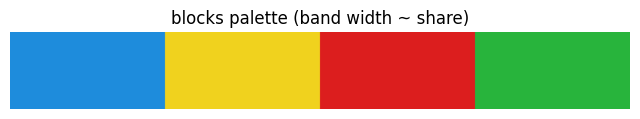

In [3]:
strip = utils.palette_strip(centers, props)
plt.figure(figsize=(8,1.2)); plt.imshow(strip); plt.title('blocks palette (band width ~ share)'); plt.axis('off'); plt.show()

## 3. A natural photo (`china.png`)

Real photos have gradients and lighting, so centres are blends rather than pure named colours.

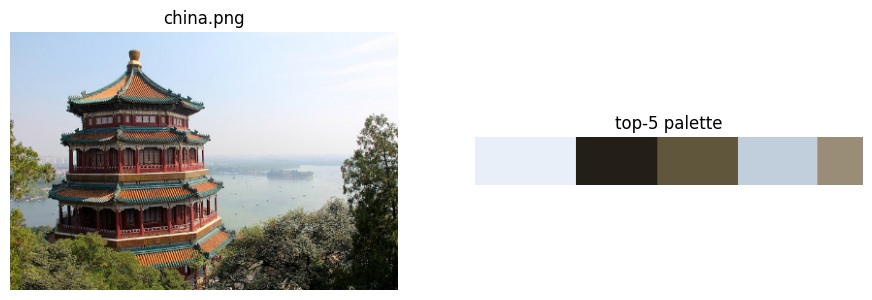

RGB (232, 239, 249)  share 0.26  -> white
RGB (35, 31, 23)  share 0.21  -> black
RGB (95, 86, 60)  share 0.21  -> brown
RGB (193, 206, 219)  share 0.21  -> white
RGB (154, 141, 120)  share 0.12  -> gray


In [4]:
china = utils.load_image('data/china.png')
centers, props = utils.dominant_colors(china, k=5)
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].imshow(china); ax[0].set_title('china.png'); ax[0].axis('off')
ax[1].imshow(utils.palette_strip(centers, props)); ax[1].set_title('top-5 palette'); ax[1].axis('off')
plt.show()
for c,p in zip(centers,props):
    print('RGB', tuple(int(v) for v in c), ' share %.2f  -> %s' % (p, utils.closest_color_name(c)))